In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import sklearn as sk

In [2]:
hex_df = pd.read_csv('C:/DISEÑO/Analisis de datos/Data/NIST_HEXANE_DATA.csv',sep = '\t', header = [0])

hex_df = hex_df.rename(columns = {'Temperature (K)': 'T', 'Pressure (bar)' : 'P', 'Cp (v, J/mol*K)' : 'Cp_V', 'Cp (l, J/mol*K)': 'Cp_L'}) 

columnas = ['T', 'P', 'Cp_V', 'Cp_L']
hex_clean = hex_df[columnas]
hex_clean.tail(5)

,T,P,Cp_V,Cp_L
596,505.62,29.460,1912.6,1396.2
597,506.17,29.701,2532.0,1836.6
598,506.72,29.944,3809.4,2779.6
599,507.27,30.191,7829.3,5937.0
600,507.82,30.441,undefined,undefined


In [3]:
print(hex_clean.head())

print(hex_clean.dtypes)

print(hex_clean.isnull().sum())

        T         P    Cp_V    Cp_L
0  177.83  0.000012  106.20  169.50
1  178.38  0.000013  106.30  169.53
2  178.93  0.000014  106.41  169.56
3  179.48  0.000015  106.52  169.59
4  180.03  0.000016  106.62  169.63
T       float64
P       float64
Cp_V        str
Cp_L        str
dtype: object
T       0
P       0
Cp_V    0
Cp_L    0
dtype: int64


In [4]:
hex_clean[hex_clean['Cp_L'] == 'undefined']

,T,P,Cp_V,Cp_L
600,507.82,30.441,undefined,undefined


In [5]:
hex_clean[hex_clean['Cp_V']=='undefined']

,T,P,Cp_V,Cp_L
600,507.82,30.441,undefined,undefined


In [6]:
hex_clean['Cp_L'] = pd.to_numeric(hex_clean['Cp_L'], errors = 'coerce')
hex_clean['Cp_V'] = pd.to_numeric(hex_clean['Cp_V'], errors = 'coerce')
print(hex_clean.isnull().sum())
print(hex_clean.dtypes)

T       0
P       0
Cp_V    1
Cp_L    1
dtype: int64
T       float64
P       float64
Cp_V    float64
Cp_L    float64
dtype: object


In [7]:
df_pressure = hex_clean[['T', 'P']].dropna()
df_cp_l = hex_clean[['T', 'Cp_L']].dropna()
df_cp_v = hex_clean[['T', 'Cp_V']].dropna()

df_pressure = df_pressure[df_pressure['T'] < 490]
df_cp_l = df_cp_l[df_cp_l['T'] < 490]
df_cp_v = df_cp_v[df_cp_v['T'] < 490]

print(df_pressure.describe())
print(df_cp_l.describe())
print(df_cp_v.describe())

                T           P
count  568.000000  568.000000
mean   333.750282    4.061466
std     90.257143    6.007571
min    177.830000    0.000012
25%    255.792500    0.022108
50%    333.755000    0.779585
75%    411.707500    5.986175
max    489.670000   23.271000
                T        Cp_L
count  568.000000  568.000000
mean   333.750282  220.857482
std     90.257143   45.885382
min    177.830000  169.500000
25%    255.792500  182.382500
50%    333.755000  209.605000
75%    411.707500  247.322500
max    489.670000  375.870000
                T        Cp_V
count  568.000000  568.000000
mean   333.750282  173.788820
std     90.257143   57.549528
min    177.830000  106.200000
25%    255.792500  127.310000
50%    333.755000  160.395000
75%    411.707500  205.237500
max    489.670000  382.890000


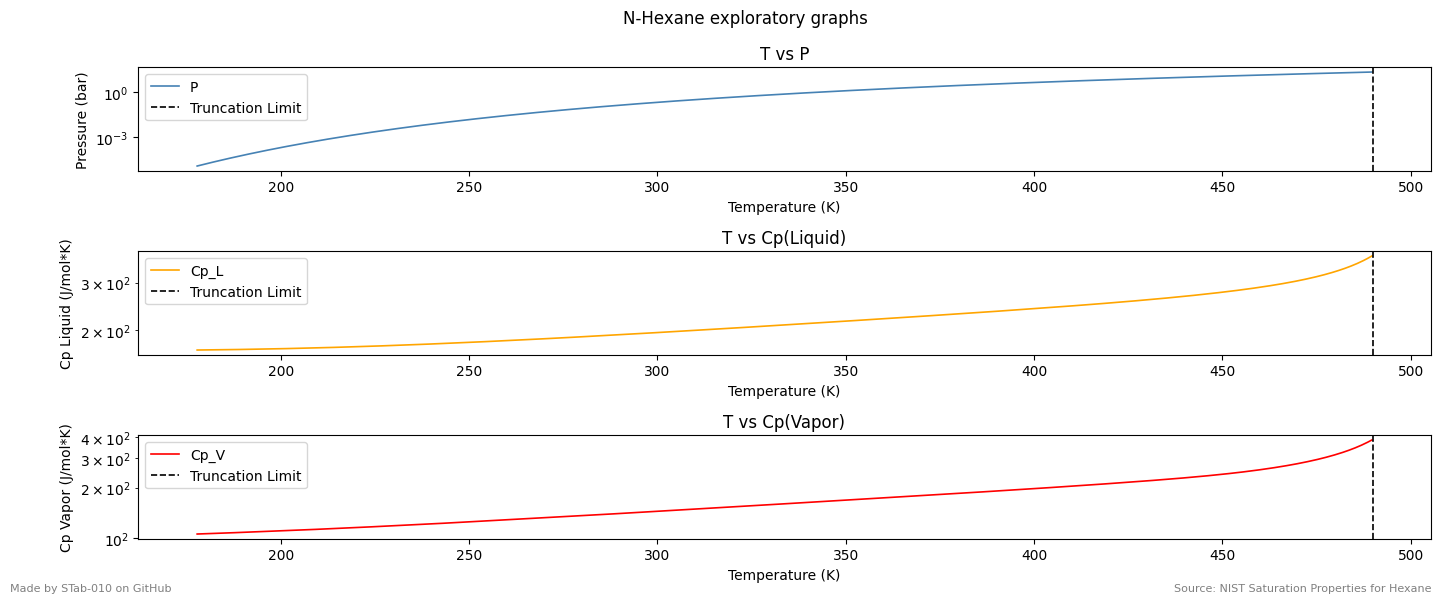

In [24]:
fig, axs = plt.subplots(3,1 , figsize  = (14,6))
fig.suptitle('N-Hexane exploratory graphs')
df_pressure.plot(ax = axs[0], linewidth = 1.2, x = 'T', y = 'P', color = 'steelblue', label = None)
axs[0].set_yscale('log')
axs[0].set_ylabel('Pressure (bar)')
axs[0].set_xlabel('Temperature (K)')
axs[0].set_title('T vs P')
axs[0].axvline(x = 490, linewidth = 1.2, linestyle = '--', color = 'black', label = 'Truncation Limit')
df_cp_l.plot(ax = axs[1], linewidth = 1.2, x = 'T', y = 'Cp_L', color = 'orange', label = None)
axs[1].set_yscale('log')
axs[1].set_ylabel('Cp Liquid (J/mol*K)')
axs[1].set_xlabel('Temperature (K)')
axs[1].set_title('T vs Cp(Liquid)')
axs[1].axvline(x = 490, linewidth = 1.2, linestyle = '--', color = 'black', label = 'Truncation Limit')
df_cp_v.plot(ax = axs[2], linewidth = 1.2, x = 'T', y = 'Cp_V', color = 'red', label = None)
axs[2].set_yscale('log')
axs[2].set_ylabel('Cp Vapor (J/mol*K)')
axs[2].set_xlabel('Temperature (K)')
axs[2].set_title('T vs Cp(Vapor)')
axs[2].axvline(x = 490, linewidth = 1.2, linestyle = '--', color = 'black', label = 'Truncation Limit')
fig.text(0.99, 0.01, 'Source: NIST Saturation Properties for Hexane', 
         ha='right', fontsize=8, alpha=0.5)
fig.text(0.09, 0.01, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)

axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.tight_layout()
plt.show()


In [9]:
print(df_pressure['T'].corr(df_pressure['P']))
print(df_cp_l['T'].corr(df_cp_l['Cp_L']))
print(df_cp_v['T'].corr(df_cp_v['Cp_V']))
df_pressure['ln_P'] = np.log(df_pressure['P'])
df_cp_l['ln_Cp_L'] = np.log(df_cp_l['Cp_L'])
df_cp_v['ln_Cp_V'] = np.log(df_cp_v['Cp_V'])

print('******************************************')

print(df_pressure['T'].corr(df_pressure['ln_P']))
print(df_cp_v['T'].corr(df_cp_v['ln_Cp_V']))
print(df_cp_l['T'].corr(df_cp_l['ln_Cp_L']))


0.8302722241324058
0.9424845479039184
0.9358981878637672
******************************************
0.9542509262175825
0.9828817567573453
0.9726121567405417


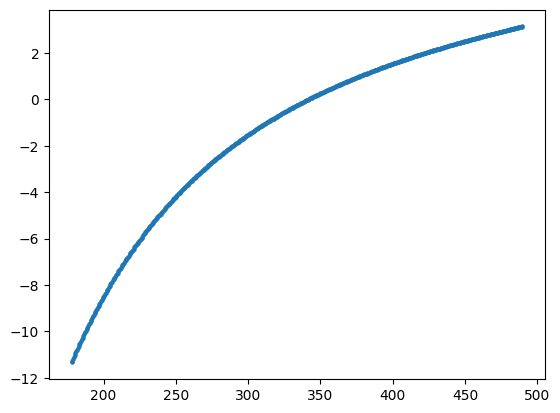

In [10]:
plt.scatter(df_pressure['T'], df_pressure['ln_P'], s=5)

## Preprocessing Desicions 
1. Range truncated to 490 K — eliminates unstable critical zone.

2. Variables transformed with ln() — improve linear correlation.

3. Three independent models — T→ln(P), T→ln(Cp_L), T→ln(Cp_V).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_p = df_pressure[['T']]
y_p = df_pressure['ln_P']

x_p_train, x_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size =0.2, random_state= 42)

X_cv = df_cp_v[['T']]
y_cv = df_cp_v['ln_Cp_V']

x_cv_train, x_cv_test, y_cv_train, y_cv_test  = train_test_split(X_cv, y_cv, test_size = 0.2, random_state= 42)

X_cl = df_cp_l[['T']]
y_cl = df_cp_l['ln_Cp_L']

x_cl_train, x_cl_test, y_cl_train, y_cl_test = train_test_split(X_cl, y_cl, test_size = 0.2, random_state= 42)

scaler_p = StandardScaler()
x_p_train_sc = scaler_p.fit_transform(x_p_train)
x_p_test_sc = scaler_p.transform(x_p_test)

scaler_cv = StandardScaler()
x_cv_train_sc = scaler_cv.fit_transform(x_cv_train)
x_cv_test_sc = scaler_cv.transform(x_cv_test)

scaler_cl = StandardScaler()
x_cl_train_sc = scaler_cl.fit_transform(x_cl_train)
x_cl_test_sc = scaler_cl.transform(x_cl_test)



1.1825839766641908 0.9093207023441969


Text(-8, -15, 'Made by STab-010 on GitHub')

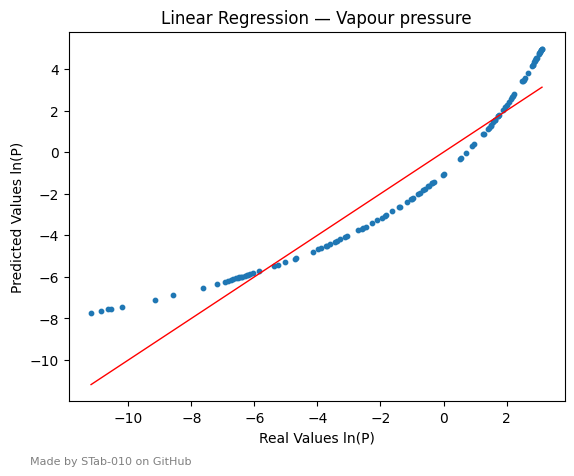

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

p_model = LinearRegression()
p_model.fit(x_p_train_sc, y_p_train)
y_p_pred = p_model.predict(x_p_test_sc)

rmse_p = root_mean_squared_error(y_p_test, y_p_pred)
r2_p = r2_score(y_p_test, y_p_pred)

print(rmse_p, r2_p)

plt.scatter(y_p_test, y_p_pred, s=10)
plt.plot([y_p_test.min(), y_p_test.max()], 
         [y_p_test.min(), y_p_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(P)')
plt.ylabel('Predicted Values ln(P)')
plt.title('Linear Regression — Vapour pressure')
plt.text(-8, -15, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)



## Conclusion -- Lineal regression Vapour pressure
- R² = 0.909, RMSE = 1.182 ln(bar)

- Systematic bias visible at the extremes of the range

- The model overestimates near the triple point and underestimates at intermediate values

- Conclusion: a model with greater expressive capacity is required

0.056814329955369024 0.9347376752266803


Text(6, 4.9, 'Made by STab-010 on GitHub')

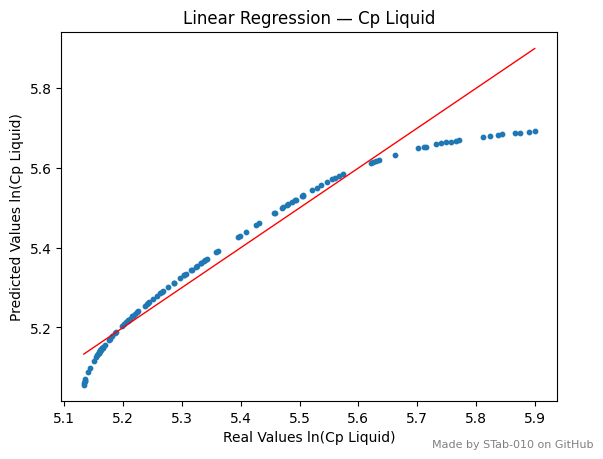

In [13]:
cl_model = LinearRegression()
cl_model.fit(x_cl_train_sc, y_cl_train)
y_cl_pred = cl_model.predict(x_cl_test_sc)

cl_rmse = root_mean_squared_error(y_cl_test, y_cl_pred)
r2_cl = r2_score(y_cl_test, y_cl_pred)

print(cl_rmse, r2_cl)

plt.scatter(y_cl_test, y_cl_pred, s=10)
plt.plot([y_cl_test.min(), y_cl_test.max()], 
         [y_cl_test.min(), y_cl_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp Liquid)')
plt.ylabel('Predicted Values ln(Cp Liquid)')
plt.title('Linear Regression — Cp Liquid')
plt.text(6,4.9, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)


## Conclusion -- Lineal regression Cp Liquid
- R² = 0.93, RMSE = 0.05 ln(J/mol*K)

- Systematic bias visible at the far right of the range

- The model underestimates near the triple point and near the critical point

- Conclusion: a model with greater expressive capacity is required

0.07398773038970592 0.9545349049656933


Text(6, 4.3, 'Made by STab-010 on GitHub')

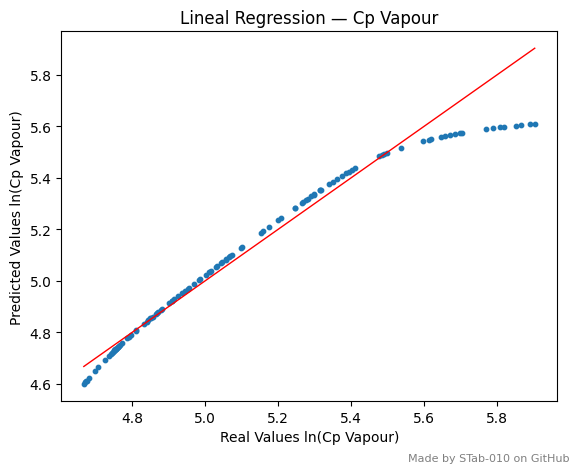

In [14]:
cv_model = LinearRegression()
cv_model.fit(x_cv_train_sc, y_cv_train)
y_cv_pred = cv_model.predict(x_cv_test_sc)

cv_rmse = root_mean_squared_error(y_cv_test, y_cv_pred)
r2_cv = r2_score(y_cv_test, y_cv_pred)

print(cv_rmse, r2_cv)

plt.scatter(y_cv_test, y_cv_pred, s=10)
plt.plot([y_cv_test.min(), y_cv_test.max()], 
         [y_cv_test.min(), y_cv_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp Vapour)')
plt.ylabel('Predicted Values ln(Cp Vapour)')
plt.title('Lineal Regression — Cp Vapour')
plt.text(6, 4.3, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)


## Conclusion — Lineal Regression Cp Vapour
- R² = 0.95, RMSE = 0.073 ln(J/mol*K)

- Systematic bias visible at the far right of the range

- The model underestimates near the triple point and near the critical point

- Conclusion: a model with greater expressive capacity is required

0.10051251198416583 0.9993449349619787
R² train: 0.9995
R² test:  0.9993


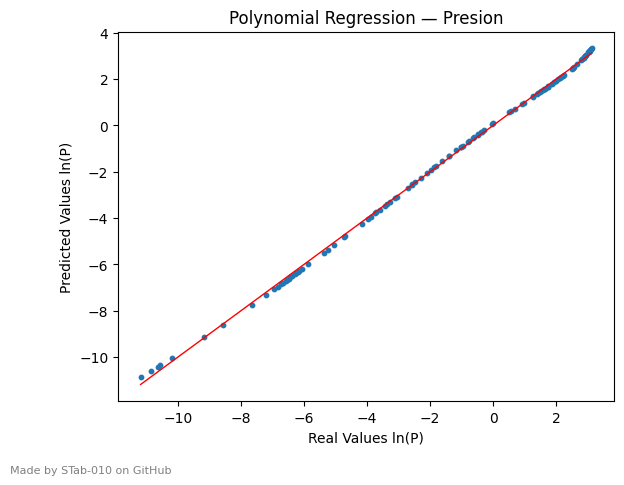

In [15]:
from sklearn.preprocessing import PolynomialFeatures

features = PolynomialFeatures(degree = 3)

xpp_train = features.fit_transform(x_p_train_sc)
xpp_test = features.transform(x_p_test_sc)

p_poly_model = LinearRegression()
p_poly_model.fit(xpp_train, y_p_train)
ypp_pred = p_poly_model.predict(xpp_test)

ppm_RMSE = root_mean_squared_error(y_p_test, ypp_pred)
ppm_r2score = r2_score(y_p_test, ypp_pred)

print(ppm_RMSE, ppm_r2score)

plt.scatter(y_p_test, ypp_pred, s=10)
plt.plot([y_p_test.min(), y_p_test.max()], 
         [y_p_test.min(), y_p_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(P)')
plt.ylabel('Predicted Values ln(P)')
plt.title('Polynomial Regression — Presion')
plt.text(-10.2, -15, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)

#Overfitting Test

ypp_pred_train = p_poly_model.predict(xpp_train)
r2_train = r2_score(y_p_train, ypp_pred_train)
print(f'R² train: {r2_train:.4f}')
print(f'R² test:  {ppm_r2score:.4f}')


0.01980135404284266 0.992072494725273


Text(6, 4.9, 'Made by STab-010 on GitHub')

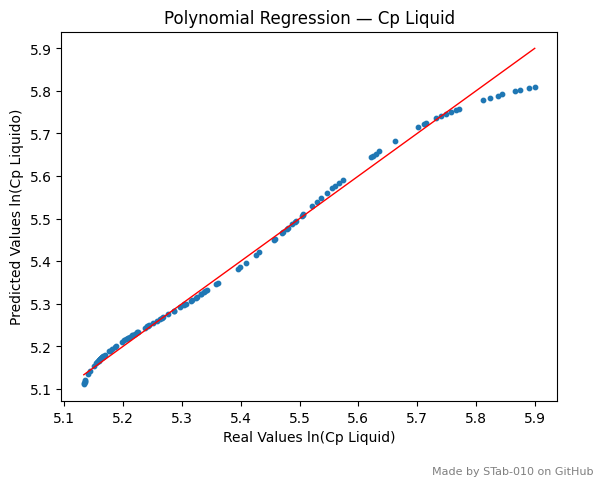

In [16]:
features_cl = PolynomialFeatures(degree = 3)
xclp_train = features_cl.fit_transform(x_cl_train_sc)
xclp_test = features_cl.transform(x_cl_test_sc)

cl_poly_model = LinearRegression()
cl_poly_model.fit(xclp_train, y_cl_train)
y_clp_pred = cl_poly_model.predict(xclp_test)

clp_RMSE = root_mean_squared_error(y_cl_test, y_clp_pred)
clp_r2score = r2_score(y_cl_test, y_clp_pred)

print(clp_RMSE, clp_r2score)

plt.scatter(y_cl_test, y_clp_pred, s=10)
plt.plot([y_cl_test.min(), y_cl_test.max()], 
         [y_cl_test.min(), y_cl_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp Liquid)')
plt.ylabel('Predicted Values ln(Cp Liquido)')
plt.title('Polynomial Regression — Cp Liquid')
plt.text(6, 4.9, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)


0.03141635480077735 0.9918027103977919


Text(6, 4.3, 'Made by STab-010 on GitHub')

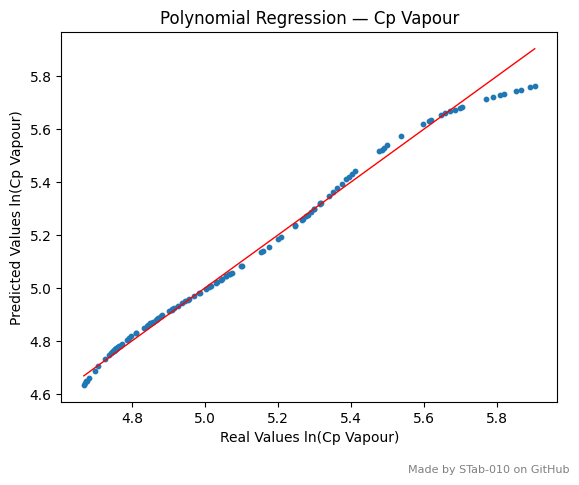

In [17]:
features_cv = PolynomialFeatures(degree = 3)
xcvp_train = features_cv.fit_transform(x_cv_train_sc)
xcvp_test = features_cv.transform(x_cv_test_sc)

cv_poly_model = LinearRegression()
cv_poly_model.fit(xcvp_train, y_cv_train)
y_cvp_pred = cv_poly_model.predict(xcvp_test)

cvp_RMSE = root_mean_squared_error(y_cv_test, y_cvp_pred)
cvp_r2score = r2_score(y_cv_test, y_cvp_pred)

print(cvp_RMSE, cvp_r2score)

plt.scatter(y_cv_test, y_cvp_pred, s=10)
plt.plot([y_cv_test.min(), y_cv_test.max()], 
         [y_cv_test.min(), y_cv_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp Vapour)')
plt.ylabel('Predicted Values ln(Cp Vapour)')
plt.title('Polynomial Regression — Cp Vapour')
plt.text(6, 4.3, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)


## Conclusion -- Polynomial regressions
| Model | R² Lineal | R² Polynomial | RMSE Lineal | RMSE Polynomial |
|--------|-----------|---------------|-------------|-----------------|
| T→ln(P) | 0.909 | 0.999 | 1.182 | 0.100 |
| T→ln(Cp_L) | 0.934 | 0.990 | 0.057 | 0.019 |
| T→ln(Cp_V) | 0.950 | 0.990 | 0.073 | 0.031 |

- Given that all three polynomial models have R² >= 0.99, it can be concluded that the polynomial models fit the dataset much better than the linear models.

- The RMSE for Pressure is much higher than the RMSEs for Cp_L and Cp_V. This is due to the dispersion of the data near the triple point and critical point regions, where the pressure ranges from 0.000012 to 23.271, while the other datasets have much smaller ranges.

- Cp_V exhibits a worse RMSE than Cp_L due to the dispersion of the data near the critical and triple points, where gaseous hexane behaves much more volatile in both than liquid hexane, thus generating a much greater data dispersion.

0.99996294324523 0.023906258329716674
R² train: 0.999994
R² test:  0.999963


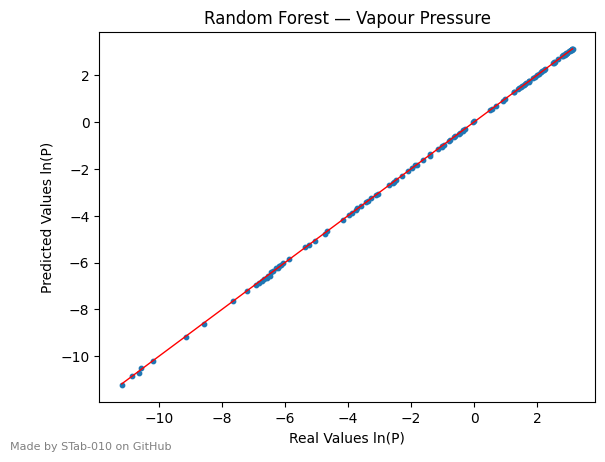

In [18]:
from sklearn.ensemble import RandomForestRegressor

fp_model = RandomForestRegressor(n_estimators=100,random_state = 42)
fp_model.fit(x_p_train,y_p_train)
y_fp_pred = fp_model.predict(x_p_test)
fpr2_score = r2_score(y_p_test,y_fp_pred)
fprmse = root_mean_squared_error(y_p_test,y_fp_pred)

print(fpr2_score, fprmse)

plt.scatter(y_p_test, y_fp_pred, s=10)
plt.plot([y_p_test.min(), y_p_test.max()], 
         [y_p_test.min(), y_p_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(P)')
plt.ylabel('Predicted Values ln(P)')
plt.title('Random Forest — Vapour Pressure')
plt.text(-9.6, -14, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)

#Overfitting Test

y_fp_pred_train = fp_model.predict(x_p_train)
r2_train = r2_score(y_p_train, y_fp_pred_train)
print(f'R² train: {r2_train:.6f}')
print(f'R² test:  {fpr2_score:.6f}')

0.999957385418209 0.0022651646168858034
R² train: 0.999989
R² test:  0.999957


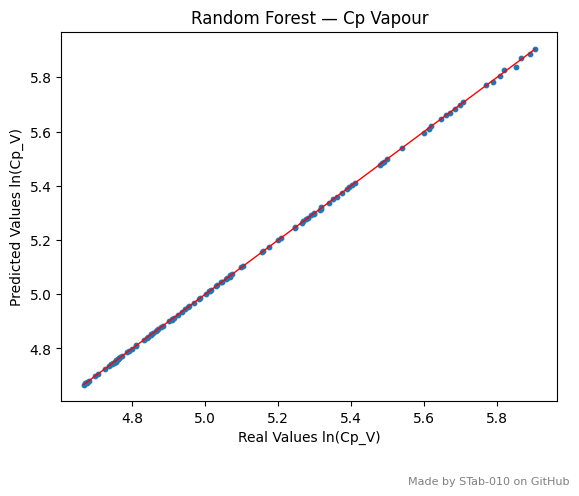

In [19]:
fcv_model = RandomForestRegressor(n_estimators=100,random_state = 42)
fcv_model.fit(x_cv_train,y_cv_train)
y_fcv_pred = fcv_model.predict(x_cv_test)
fcvr2_score = r2_score(y_cv_test,y_fcv_pred)
fcvrmse = root_mean_squared_error(y_cv_test,y_fcv_pred)

print(fcvr2_score, fcvrmse)

plt.scatter(y_cv_test, y_fcv_pred, s=10)
plt.plot([y_cv_test.min(), y_cv_test.max()], 
         [y_cv_test.min(), y_cv_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp_V)')
plt.ylabel('Predicted Values ln(Cp_V)')
plt.title('Random Forest — Cp Vapour')
plt.text(6, 4.3, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)

#Overfitting Test
y_fcv_pred_train = fcv_model.predict(x_cv_train)
r2_train = r2_score(y_cv_train, y_fcv_pred_train)
print(f'R² train: {r2_train:.6f}')
print(f'R² test:  {fcvr2_score:.6f}')

0.9999569333657022 0.0014594764288296924
R² train: 0.999988
R² test:  0.999957


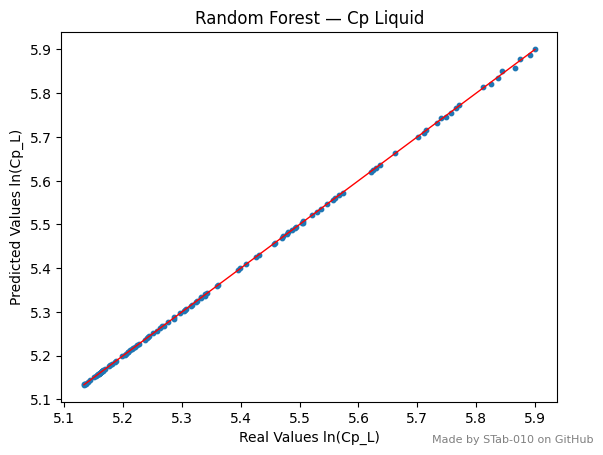

In [20]:
fcl_model = RandomForestRegressor(n_estimators=100,random_state = 42)
fcl_model.fit(x_cl_train,y_cl_train)
y_fcl_pred = fcl_model.predict(x_cl_test)
fclr2_score = r2_score(y_cl_test,y_fcl_pred)
fclrmse = root_mean_squared_error(y_cl_test,y_fcl_pred)

print(fclr2_score, fclrmse)

plt.scatter(y_cl_test, y_fcl_pred, s=10)
plt.plot([y_cl_test.min(), y_cl_test.max()], 
         [y_cl_test.min(), y_cl_test.max()], 
         color='red', linewidth=1)
plt.xlabel('Real Values ln(Cp_L)')
plt.ylabel('Predicted Values ln(Cp_L)')
plt.title('Random Forest — Cp Liquid')
plt.text(6, 5, 'Made by STab-010 on GitHub', 
         ha='right', fontsize=8, alpha=0.5)

#Overfitting test
y_fcl_pred_train = fcl_model.predict(x_cl_train)
r2_train = r2_score(y_cl_train, y_fcl_pred_train)
print(f'R² train: {r2_train:.6f}')
print(f'R² test:  {fclr2_score:.6f}')

## Conclusions — Random Forest Pressure, Cp liquid and Cp vapour
| Model | R² Lineal | R² Polynomial |R² Random Forest| RMSE Lineal | RMSE Polynomial | RMSE Random Forest |
|--------|-----------|---------------|--------------|-------------|-----------------|------------------|
| T→ln(P) | 0.909 | 0.999 |0.999996| 1.182 | 0.100 |0.023|
| T→ln(Cp_L) | 0.934 | 0.990 |0.999995| 0.057 | 0.019 |0.002|
| T→ln(Cp_V) | 0.950 | 0.990 |0.999995| 0.073 | 0.031 |0.001|

- It can be seen that Random Forest far surpassed the Linear and Polynomial models in its ability to predict and couple to the dataset. 

- Seeing that the R2 Train and Test of the 3 Random Forest models are almost the same, we can say that the model optimally generalized the data of the set, manages to make accurate predictions and manages to capture patterns without memorizing.

- If a model to predict vapour pressure had to be chosen by statistical parsimony, the Random Forest model would be chosen, Since it is not the most complex model available, it manages to generalize the data without memorization, and does not take up much space.

- The major limitation of these models is their inability to predict data outside the specified range; in other words, they cannot reliably extrapolate. It's also important to note that these are black-box models, as they do not yield any thermodynamic equations or physical interpretations.

# Final conclusions; Can ML Reliably Predict Thermodynamic Properties of N-hexane From Just Temperature?
The answer to this question is YES, ML can predict the thermodynamic properties of n-hexane from just temperature, but only in a defined range. In this project it is proved that the models used have a strong and clear limitation, they cannot predict properties and do not generalize correctly outside of the defined range, and also, The Random Forest cannot physically interpret the properties of n-hexane. Thus, we can infer that if we give the models data greater than 490 Kelvin (close to the critical point), the predictions become unreliable and the models do not adapt to the data.

It can be seen that the models adapted very well from the linear regression, even so, given the nature of the data and their non-linear behavior, as its expressed on the next table:

| Model | R² Lineal | R² Polynomial |R² Random Forest| RMSE Lineal | RMSE Polynomial | RMSE Random Forest |
|--------|-----------|---------------|--------------|-------------|-----------------|------------------|
| T→ln(P) | 0.909 | 0.999 |0.999996| 1.182 | 0.100 |0.023|
| T→ln(Cp_L) | 0.934 | 0.990 |0.999995| 0.057 | 0.019 |0.002|
| T→ln(Cp_V) | 0.950 | 0.990 |0.999995| 0.073 | 0.031 |0.001|

We can see that the Random Forest model achieved the highest R² and lowest RMSE of all the models.

Practically, a random forest model would be recommended for the prediction of the thermodynamic properties of vapor pressure, Liquid Cp and Vapor Cp,likewise, this model can be applied to petrochemical, vegetable oil and chemical synthesis industries.

It is remarkable to understand that the reliability of predictions depends solely on the reliability of the data themselves, in this case, NIST databases.

For the future; with more time, I would have used models to extrapolate the data outside the chosen range, thus testing the reliability of ML models for predicting the thermodynamic properties of molecules.